## Movement analysis (Study 2)

The following script: 
1. Pre-processes the movement data.
1. Calculates alpha and RMS for each participant.
2. Calculates complexity matching and linear covariance within actual pairs and pseudo pairs.
3. Calculates complexity matching and linear covariance between each participant and the background noise envelope (using both actual and pseudo pairings).
4. Merges the complexity matching datasets at each step.

### Calculates Alpha and RMS

Processed 550/550 files
[INFO] Global template computed with mode='none'


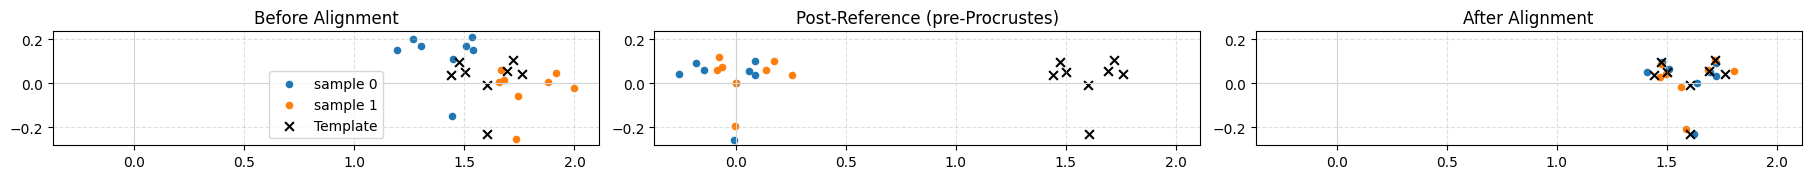

Results saved → results/study2/study2_dfa_rms.csv


In [2]:
# Import required libraries
import numpy as np
import os
import pandas as pd
from IPython.display import clear_output
from utils.keypoint_utils import *   # extract_keypoints
from utils.cleaning_utils import *   # pre-processing
from utils.alignment_utils import *  # alignment
from utils.feature_utils import compute_velocity, head_center_series_temples
from utils.dfa_utils import perform_dfa

# =========================
# Parameters
# =========================
directory = "raw data/study2"                       # Path to input files
conditions_file = "raw data/study2_conditions.csv"  # Path to conditions file
keypoint_sets = [["template", "temple"]]            # Keypoint sets to extract
window_size = [1200]                                # ~20s at 60 fps
window_overlap = 0.5                                # 50% overlap
fps = 60                                            # Sampling rate (Hz)

# =========================
# Main Loop
# =========================
def main(symmetrization_mode="none", allow_rotation=True, fps=fps):

    raw_windows = []   # (window_df, metadata) for valid windows only
    full_trials = []   # for template building
    rows = []          # final results (both valid + invalid windows)
    expected_cols = None

    # Load conditions mapping
    conditions_df = pd.read_csv(conditions_file)
    
    # Create a dictionary for quick lookup: (session, trial) -> condition
    conditions_dict = {
        (row['session'], row['trial']): row['condition'] 
        for _, row in conditions_df.iterrows()
    }

    # Get all CSV files in directory
    all_files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    total_files = len(all_files)
    file_counter = 0

    # === Pass 1: Load all data and slice into windows ===
    for filename in all_files:
        file_counter += 1
        
        # Extract session, trial, and participant from filename
        # Expected format: S{session}_T{trial}_{participant}.csv
        parts = filename.replace('.csv', '').split('_')
        if len(parts) < 3:
            print(f"[SKIP] {filename} - unexpected filename format")
            continue
            
        session_number = int(parts[0].replace('S', ''))
        trial_number = int(parts[1].replace('T', ''))
        role = parts[2].capitalize()  # 'left' or 'right' -> 'Left' or 'Right'
        
        # Look up condition
        condition = conditions_dict.get((session_number, trial_number))
        if condition is None:
            print(f"[SKIP] {filename} - no condition found for session {session_number}, trial {trial_number}")
            continue

        # Load and preprocess data
        pose_file = os.path.join(directory, filename)
        if not os.path.exists(pose_file):
            continue
        
        data = pd.read_csv(pose_file)
        selected = extract_keypoints(data, sets=keypoint_sets[0])
        selected = normalize_by_resolution(selected)
        selected = mask_low_confidence(selected, threshold=0.3)
        selected = interpolate_nans(selected, max_gap=60)
        selected = filter_data_safe_preserve_nans(selected)
        selected.columns = [col.strip() for col in selected.columns]

        # Column schema harmonisation
        if expected_cols is None and not selected.empty:
            expected_cols = order_xy_pairs(selected.columns)
        for col in expected_cols:
            if col not in selected.columns:
                selected[col] = np.nan
        selected = selected[expected_cols]

        # Keep full trial for template
        full_trials.append(selected)

        # Windowing
        for ws in window_size:
            win_indices = get_window_indices(len(selected), ws, window_overlap)
            for w_idx, (start, end) in enumerate(win_indices):
                window = selected.iloc[start:end].reset_index(drop=True)
                meta = {
                    'pair': session_number,
                    'trial': trial_number,
                    'role': role,
                    'environment': condition,
                    'window_index': w_idx,
                    'window_start': start,
                    'window_end': end
                }

                # NaN check
                if np.isnan(window.values).any():
                    # Append immediately with NaN stats
                    rows.append({**meta,
                                 'head_mag_alpha': np.nan,
                                 'head_mag_rms': np.nan})
                else:
                    raw_windows.append((window, meta))

        clear_output(wait=True)
        print(f"Processed {file_counter}/{total_files} files")
    # Sanity check NaN windows
    if not raw_windows:
        print("[ERROR] No valid windows found.")
        return
    if not full_trials:
        print("[ERROR] No valid full trials found for template building.")
        return

    # Build global template for procrustes alignment
    X_raw = pd.concat(full_trials, ignore_index=True).dropna().astype(np.float32)
    global_template = build_symmetric_face_template(X_raw, expected_cols, mode=symmetrization_mode)
    print(f"[INFO] Global template computed with mode='{symmetrization_mode}'")

    # Diagnostic plot for alignment
    plot_alignment_diagnostics_face(
        global_template, raw_windows, expected_cols, align_face_keypoints,
        reference="Nose", procrustes=True, allow_rotation=allow_rotation
    )

    # === Pass 2: Align windows, compute DFA + RMS ===
    for window, meta in raw_windows:
        aligned_X, _ = align_face_keypoints(
            window, expected_cols,
            reference="Nose",
            template=global_template,
            use_procrustes=True,
            allow_rotation=allow_rotation
        )

        poses = aligned_X.reshape(-1, len(expected_cols)//2, 2)

        aligned_df = rebuild_aligned_dataframe(
            poses.reshape(-1, len(expected_cols)), expected_cols
        )

        # Compute head center series (temples) and velocity
        cx, cy = head_center_series_temples(aligned_df)
        _, _, speed = compute_velocity(cx, cy, fps=fps)

        # RMS of head speed
        head_mag_rms = float(np.sqrt(np.nanmean(speed**2)))

        # DFA on head speed
        dfa_alpha_head_mag = float(
            perform_dfa(pd.DataFrame({"head_speed": speed}), min_window_size=8).get("head_speed", np.nan)
        )

        # Append valid row
        rows.append({**meta,
                     'head_mag_alpha': dfa_alpha_head_mag,
                     'head_mag_rms': head_mag_rms})

    # ==============================
    # Save results
    # ==============================
    out_path = f'results/study2/study2_dfa_rms.csv'
    pd.DataFrame(rows).to_csv(out_path, index=False)
    print(f"Results saved → {out_path}")

if __name__ == "__main__":
    main(symmetrization_mode="none", allow_rotation=True, fps=fps)


### Actual Pairings

#### Calculates Dyadic Complexity Matching & RMS Cross-Correlation

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import os
from utils.feature_utils import safe_corr, fisher_z

# ==============================
# Load window-level results
# ==============================
input_path = "results/study2/study2_dfa_rms.csv" 
df = pd.read_csv(input_path)

# ==============================
# Pivot data so Left/Right are columns
# ==============================
df_pivot = df.pivot_table(
    index=["pair", "trial", "environment", "window_index", "window_start", "window_end"],
    columns="role",
    values=["head_mag_rms", "head_mag_alpha"]
).reset_index()

# Flatten column names
df_pivot.columns = [
    "_".join([c for c in col if c]) if isinstance(col, tuple) else col
    for col in df_pivot.columns
]

# ==============================
# Group and correlate
# ==============================
MIN_PROP = 0.5  # require at least 50% overlapping windows for valid correlation

corr_results = []
total_groups = 0
dropped_groups = 0
overlap_props = []

for (pair, trial, environment), group in df_pivot.groupby(["pair", "trial", "environment"]):
    total_groups += 1
    group = group.sort_values("window_index")

    # Keep only windows where both participants have valid data
    valid = group.dropna(subset=[
        "head_mag_rms_Left", "head_mag_rms_Right",
        "head_mag_alpha_Left", "head_mag_alpha_Right"
    ])

    n_total = len(group)
    n_used = len(valid)
    prop_used = n_used / n_total if n_total > 0 else 0
    overlap_props.append(prop_used)

    if prop_used < MIN_PROP or n_used < 3:
        dropped_groups += 1
        rms_r = np.nan
        dfa_r = np.nan
    else:
        rms_r = safe_corr(valid["head_mag_rms_Left"], valid["head_mag_rms_Right"])
        dfa_r = safe_corr(valid["head_mag_alpha_Left"], valid["head_mag_alpha_Right"])

    corr_results.append({
        "pair": pair,
        "trial": trial,
        "environment": environment,
        "rms_corr": rms_r,
        "rms_corr_z": fisher_z(rms_r),
        "alpha_corr": dfa_r,
        "alpha_corr_z": fisher_z(dfa_r)
    })

# ==============================
# Print summary
# ==============================
overlap_props = np.array(overlap_props)
mean_overlap = np.nanmean(overlap_props)
sd_overlap = np.nanstd(overlap_props)
prop_retained = 1 - (dropped_groups / total_groups)

print("\n" + "="*60)
print("CROSS-CORRELATION SUMMARY (after alignment filter)")
print("="*60)
print(f"Total groups processed: {total_groups}")
print(f"Groups dropped (below {MIN_PROP*100:.0f}% overlap): {dropped_groups} ({100*dropped_groups/total_groups:.1f}%)")
print(f"Mean proportion of overlapping windows: {mean_overlap:.2f} ± {sd_overlap:.2f}")
print(f"Proportion of groups retained: {prop_retained:.2f}")
print("="*60)

# ==============================
# Save results
# ==============================
corr_df = pd.DataFrame(corr_results)
output_path = "results/study2/study2_dfa_rms_corr.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
corr_df.to_csv(output_path, index=False)

print(f"Correlation results saved → {output_path}")


CROSS-CORRELATION SUMMARY (after alignment filter)
Total groups processed: 278
Groups dropped (below 50% overlap): 50 (18.0%)
Mean proportion of overlapping windows: 0.76 ± 0.31
Proportion of groups retained: 0.82
Correlation results saved → results/study2/study2_dfa_rms_corr.csv


#### Calculates Environmental Complexity Matching and RMS Cross-Correlation

In [4]:
# Import required libraries 
import os

# ==============================
# Load stimulus information
# ==============================
noise_dir = "stimuli/study2"
noise_dfs = {}
for file in os.listdir(noise_dir):
    if file.endswith("_windows.csv"):
        env_name = file.split("_", 1)[0]
        df_noise = pd.read_csv(os.path.join(noise_dir, file))
        df_noise["environment"] = env_name
        noise_dfs[env_name] = df_noise

noise_all = pd.concat(noise_dfs.values(), ignore_index=True)

# Merge noise values into df_pivot (stimulus never missing)
df_with_noise = df_pivot.merge(
    noise_all,
    on=["environment", "window_index"],
    how="left"
)

# ==============================
# Compute participant–stimulus correlations
# ==============================
MIN_PROP = 0.5  # require at least 50% of windows for participant–stimulus correlation

noise_results = []
total_groups = 0
dropped_groups = 0
overlap_props = []

for (pair, trial, environment), group in df_with_noise.groupby(["pair", "trial", "environment"]):
    total_groups += 1
    n_total = len(group)

    # Remove missing data for each participant separately (stimulus has no NAs)
    valid_left  = group.dropna(subset=["head_mag_rms_Left", "head_mag_alpha_Left"])
    valid_right = group.dropna(subset=["head_mag_rms_Right", "head_mag_alpha_Right"])

    n_used_left = len(valid_left)
    n_used_right = len(valid_right)
    prop_left = n_used_left / n_total if n_total > 0 else 0
    prop_right = n_used_right / n_total if n_total > 0 else 0

    # Drop group if either participant has too little valid data
    if (prop_left < MIN_PROP) or (prop_right < MIN_PROP) or (n_used_left < 3) or (n_used_right < 3):
        dropped_groups += 1
        rms_corr_stimulus = np.nan
        alpha_corr_stimulus = np.nan
    else:
        rms_corr_stimulus = np.nanmean([
            safe_corr(valid_left["head_mag_rms_Left"], group.loc[valid_left.index, "rms_noise"]),
            safe_corr(valid_right["head_mag_rms_Right"], group.loc[valid_right.index, "rms_noise"])
        ])
        alpha_corr_stimulus = np.nanmean([
            safe_corr(valid_left["head_mag_alpha_Left"], group.loc[valid_left.index, "alpha_noise"]),
            safe_corr(valid_right["head_mag_alpha_Right"], group.loc[valid_right.index, "alpha_noise"])
        ])

    overlap_props.extend([prop_left, prop_right])

    noise_results.append({
        "pair": pair,
        "trial": trial,
        "environment": environment,
        "rms_corr_stimulus": rms_corr_stimulus,
        "rms_corr_z_stimulus": fisher_z(rms_corr_stimulus),
        "alpha_corr_stimulus": alpha_corr_stimulus,
        "alpha_corr_z_stimulus": fisher_z(alpha_corr_stimulus)
    })

# ==============================
# Print summary
# ==============================
overlap_props = np.array(overlap_props)
mean_overlap = np.nanmean(overlap_props)
sd_overlap = np.nanstd(overlap_props)
prop_retained = 1 - (dropped_groups / total_groups)

print("\n" + "="*60)
print("PARTICIPANT–STIMULUS CORRELATION SUMMARY (after alignment filter)")
print("="*60)
print(f"Total groups processed: {total_groups}")
print(f"Groups dropped (below {MIN_PROP*100:.0f}% overlap): {dropped_groups} ({100*dropped_groups/total_groups:.1f}%)")
print(f"Mean proportion of valid windows per participant: {mean_overlap:.2f} ± {sd_overlap:.2f}")
print(f"Proportion of groups retained: {prop_retained:.2f}")
print("="*60)

# ==============================
# Convert to DataFrame
# ==============================
noise_df = pd.DataFrame(noise_results)

# ==============================
# Merge noise correlations into partner correlations
# ==============================
corr_df = corr_df.merge(
    noise_df,
    on=["pair", "trial", "environment"],
    how="left"
)

# ==============================
# Save merged file
# ==============================
output_path = "results/study2/study2_dfa_rms_corr_with_noise.csv"
corr_df.to_csv(output_path, index=False)
print(f"Partner + noise correlations saved → {output_path}")



PARTICIPANT–STIMULUS CORRELATION SUMMARY (after alignment filter)
Total groups processed: 278
Groups dropped (below 50% overlap): 48 (17.3%)
Mean proportion of valid windows per participant: 0.88 ± 0.24
Proportion of groups retained: 0.83
Partner + noise correlations saved → results/study2/study2_dfa_rms_corr_with_noise.csv


### Pseudo Pairings

#### Calculates Pseudo Complexity Matching & RMS Cross-Correlation

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import os
from utils.feature_utils import safe_corr, fisher_z

# ==============================
# Load window-level results
# ==============================
input_path = "results/study2/study2_dfa_rms.csv"
df = pd.read_csv(input_path)

# ==============================
# Pseudo-pairs analysis (pooled across roles, Fisher z before averaging)
# ==============================
MIN_PROP = 0.5  # require at least 50% overlapping valid windows

pseudo_results = []
total_real_pairs = 0
dropped_corrs = 0
overlap_props = []
total_corrs_attempted = 0

# Group by environment × trial
for (environment, trial), group in df.groupby(["environment", "trial"]):
    for pair_id in group["pair"].unique():
        # Extract the two real participants
        p_left = group[(group["pair"] == pair_id) & (group["role"] == "Left")]
        p_right = group[(group["pair"] == pair_id) & (group["role"] == "Right")]
        if p_left.empty or p_right.empty:
            continue

        total_real_pairs += 1
        pseudo_rms_corrs, pseudo_alpha_corrs = [], []

        # Compare to all other participants in same trial/environment
        for other_pair in group["pair"].unique():
            if other_pair == pair_id:
                continue

            for role in ["Left", "Right"]:
                other = group[(group["pair"] == other_pair) & (group["role"] == role)]
                if other.empty:
                    continue

                # Align windows (shared window_start & window_end)
                merged_L = pd.merge(p_left, other, on=["window_start", "window_end"], suffixes=("", "_other"))
                merged_R = pd.merge(p_right, other, on=["window_start", "window_end"], suffixes=("", "_other"))

                for merged in [merged_L, merged_R]:
                    if merged.empty:
                        continue
                    
                    # Count attempted correlations
                    total_corrs_attempted += 1

                    # --- Determine proportion of overlapping valid windows ---
                    mask_valid_rms = merged["head_mag_rms"].notna() & merged["head_mag_rms_other"].notna()
                    mask_valid_alpha = merged["head_mag_alpha"].notna() & merged["head_mag_alpha_other"].notna()
                    prop_used_rms = mask_valid_rms.mean()
                    prop_used_alpha = mask_valid_alpha.mean()
                    prop_used = np.nanmean([prop_used_rms, prop_used_alpha])
                    overlap_props.append(prop_used)

                    # Skip if too little overlap
                    if prop_used < MIN_PROP or mask_valid_rms.sum() < 3:
                        dropped_corrs += 1
                        continue

                    # --- Compute correlations using valid overlapping rows ---
                    rms_r = safe_corr(
                        merged.loc[mask_valid_rms, "head_mag_rms"],
                        merged.loc[mask_valid_rms, "head_mag_rms_other"]
                    )
                    alpha_r = safe_corr(
                        merged.loc[mask_valid_alpha, "head_mag_alpha"],
                        merged.loc[mask_valid_alpha, "head_mag_alpha_other"]
                    )

                    if not pd.isna(rms_r):
                        pseudo_rms_corrs.append(fisher_z(rms_r))
                    if not pd.isna(alpha_r):
                        pseudo_alpha_corrs.append(fisher_z(alpha_r))

        # Average Fisher-z values, then back-transform
        mean_rms_z = np.nanmean(pseudo_rms_corrs) if pseudo_rms_corrs else np.nan
        mean_alpha_z = np.nanmean(pseudo_alpha_corrs) if pseudo_alpha_corrs else np.nan

        pseudo_results.append({
            "pair": pair_id,
            "environment": environment,
            "trial": trial,
            "rms_pseudo_corr": np.tanh(mean_rms_z) if not pd.isna(mean_rms_z) else np.nan,
            "rms_pseudo_corr_z": mean_rms_z,
            "alpha_pseudo_corr": np.tanh(mean_alpha_z) if not pd.isna(mean_alpha_z) else np.nan,
            "alpha_pseudo_corr_z": mean_alpha_z
        })

# ==============================
# Print summary
# ==============================
overlap_props = np.array(overlap_props)
mean_overlap = np.nanmean(overlap_props)
sd_overlap = np.nanstd(overlap_props)
prop_dropped = dropped_corrs / total_corrs_attempted if total_corrs_attempted > 0 else np.nan 

print("\n" + "="*60)
print("PSEUDO-PAIR CORRELATION SUMMARY (after valid-data filter)")
print("="*60)
print(f"Total real pairs processed: {total_real_pairs}")
print(f"Total pseudo-stimulus correlations attempted: {total_corrs_attempted}")
print(f"Total pseudo correlations dropped (below {MIN_PROP*100:.0f}% overlap): {dropped_corrs} ({prop_dropped*100:.1f}%)")
print(f"Mean proportion of valid overlapping windows across pseudo-pairs: {mean_overlap:.2f} ± {sd_overlap:.2f}")
print("="*60)

# ==============================
# Save results
# ==============================
pseudo_df = pd.DataFrame(pseudo_results)
output_path = "results/study2/study2_dfa_rms_pseudo_corr.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
pseudo_df.to_csv(output_path, index=False)

print(f"Pseudo correlations saved → {output_path}")


PSEUDO-PAIR CORRELATION SUMMARY (after valid-data filter)
Total real pairs processed: 272
Total pseudo-stimulus correlations attempted: 32252
Total pseudo correlations dropped (below 50% overlap): 5126 (15.9%)
Mean proportion of valid overlapping windows across pseudo-pairs: 0.78 ± 0.28
Pseudo correlations saved → results/study2/study2_dfa_rms_pseudo_corr.csv


#### Calculates Environmental Complexity Matching and RMS Cross-Correlation

In [6]:
# ==============================
# Pseudo participant–stimulus correlations
# ==============================
MIN_PROP = 0.5  # require at least 50% valid overlapping windows

pseudo_stimulus_results = []
total_real_pairs = 0
dropped_corrs = 0
overlap_props = []
total_corrs_attempted = 0 

# Loop over env × trial
for (trial, environment), group in df_with_noise.groupby(["trial", "environment"]):
    for pair_id in group["pair"].unique():
        p_left = group[group["pair"] == pair_id][["window_index", "head_mag_rms_Left", "head_mag_alpha_Left"]]
        p_right = group[group["pair"] == pair_id][["window_index", "head_mag_rms_Right", "head_mag_alpha_Right"]]
        if p_left.empty or p_right.empty:
            continue

        total_real_pairs += 1
        pseudo_rms_z, pseudo_alpha_z = [], []

        # Loop over *other* environments (pseudo stimuli)
        for other_env in df_with_noise["environment"].unique():
            if other_env == environment:
                continue

            # Grab the noise windows for the other environment    
            noise_other = noise_all[noise_all["environment"] == other_env][
                ["window_index", "rms_noise", "alpha_noise"]
            ]

            # Align participants with the wrong stimulus by window index
            merged_L = pd.merge(p_left, noise_other, on="window_index", how="inner")
            merged_R = pd.merge(p_right, noise_other, on="window_index", how="inner")

            for merged, rms_col, alpha_col in [
                (merged_L, "head_mag_rms_Left", "head_mag_alpha_Left"),
                (merged_R, "head_mag_rms_Right", "head_mag_alpha_Right"),
            ]:
                if merged.empty:
                    continue

                # Count attempted correlations
                total_corrs_attempted += 1 

                # --- Determine proportion of valid overlapping windows ---
                mask_valid_rms = merged[rms_col].notna() & merged["rms_noise"].notna()
                mask_valid_alpha = merged[alpha_col].notna() & merged["alpha_noise"].notna()
                prop_used_rms = mask_valid_rms.mean()
                prop_used_alpha = mask_valid_alpha.mean()
                prop_used = np.nanmean([prop_used_rms, prop_used_alpha])
                overlap_props.append(prop_used)

                # Skip if insufficient overlap
                if prop_used < MIN_PROP or mask_valid_rms.sum() < 3:
                    dropped_corrs += 1
                    continue

                # --- Compute correlations using valid rows only ---
                rms_r = safe_corr(
                    merged.loc[mask_valid_rms, rms_col],
                    merged.loc[mask_valid_rms, "rms_noise"]
                )
                alpha_r = safe_corr(
                    merged.loc[mask_valid_alpha, alpha_col],
                    merged.loc[mask_valid_alpha, "alpha_noise"]
                )

                if not pd.isna(rms_r):
                    pseudo_rms_z.append(fisher_z(rms_r))
                if not pd.isna(alpha_r):
                    pseudo_alpha_z.append(fisher_z(alpha_r))

        # Average Fisher z’s, then back-transform
        mean_rms_z = np.nanmean(pseudo_rms_z) if pseudo_rms_z else np.nan
        mean_alpha_z = np.nanmean(pseudo_alpha_z) if pseudo_alpha_z else np.nan

        pseudo_stimulus_results.append({
            "pair": pair_id,
            "trial": trial,
            "environment": environment,
            "rms_pseudo_corr_stimulus": np.tanh(mean_rms_z) if not pd.isna(mean_rms_z) else np.nan,
            "rms_pseudo_corr_z_stimulus": mean_rms_z,
            "alpha_pseudo_corr_stimulus": np.tanh(mean_alpha_z) if not pd.isna(mean_alpha_z) else np.nan,
            "alpha_pseudo_corr_z_stimulus": mean_alpha_z
        })

# ==============================
# Print summary
# ==============================
overlap_props = np.array(overlap_props)
mean_overlap = np.nanmean(overlap_props)
sd_overlap = np.nanstd(overlap_props)

print("\n" + "="*60)
print("PSEUDO PARTICIPANT–STIMULUS CORRELATION SUMMARY (after valid-data filter)")
print("="*60)
print(f"Total real pairs processed: {total_real_pairs}")
print(f"Total pseudo-stimulus correlations attempted: {total_corrs_attempted}")
print(f"Total pseudo-stimulus correlations dropped (below {MIN_PROP*100:.0f}% overlap): "
      f"{dropped_corrs} ({prop_dropped*100:.1f}%)")
print(f"Mean proportion of valid overlapping windows: {mean_overlap:.2f} ± {sd_overlap:.2f}")
print("="*60)

# ==============================
# Convert to DataFrame and merge
# ==============================
pseudo_stimulus_df = pd.DataFrame(pseudo_stimulus_results)

pseudo_df = pseudo_df.merge(
    pseudo_stimulus_df,
    on=["pair", "trial", "environment"],
    how="left"
)

# ==============================
# Save merged file
# ==============================
output_path = "results/study2/study2_dfa_rms_pseudo_corr_with_noise.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
pseudo_df.to_csv(output_path, index=False)
print(f"Pseudo correlations (partner + stimulus) saved → {output_path}")


PSEUDO PARTICIPANT–STIMULUS CORRELATION SUMMARY (after valid-data filter)
Total real pairs processed: 278
Total pseudo-stimulus correlations attempted: 1668
Total pseudo-stimulus correlations dropped (below 50% overlap): 154 (15.9%)
Mean proportion of valid overlapping windows: 0.88 ± 0.24
Pseudo correlations (partner + stimulus) saved → results/study2/study2_dfa_rms_pseudo_corr_with_noise.csv
